# Decomposing coherent-GGI change into female and male adoption

The coherent GGI is a ratio, so its log change splits **exactly** into a female and a male term:

```
GGI_ct           = female_ct / male_ct
delta_log_GGI    = log(GGI_c,t1)    - log(GGI_c,t0)
female_component = log(female_c,t1) - log(female_c,t0)
male_component   = -[log(male_c,t1) - log(male_c,t0)]

delta_log_GGI    = female_component + male_component        (identity)
```

The point of the exercise is that a **narrowing gap is not the same thing as women gaining access**.
The gap also narrows when men lose access, or when both sexes lose access and men lose more. Those
are parity improvements without access expansion, and they are labelled as such everywhere below —
never as improved digital access.

Every table is built by `src/15_coherent_ggi_decomposition.py`; this notebook only plots.

Primary interval **2015–2025**, with 2015–2020, 2020–2025 and all consecutive annual pairs also
computed. 2026 is excluded as a partial year (D18).

**Parity is the ceiling** (`params.level_ceiling_ctrl`). Where women's predicted adoption exceeds
men's there is no gap against women, so movement above parity must not read as a widening gap. The
cap is applied to the **female level** (`female* = min(female, male)`), which gives the same series
as capping the GGI at 1 but keeps `GGI* = female*/male` a genuine ratio — so the identity above
still holds exactly. Capping the ratio directly would break it. Rows where the cap binds are
flagged `ceiling_binding`; there the female component measures change in `min(female, male)` rather
than in female adoption alone (D25).

Countries **already at or above parity at both endpoints** are separated into their own category
(**8**) rather than dropped. There was no gap against women to close, so their near-zero change is a
standing state, not a negligible movement — but they stay in the denominator, because dropping them
would remove countries non-randomly by region and income. A country that *crosses into* parity
during the window is **not** in category 8: its convergence is the finding, and it keeps its
convergence category (D26).

In [1]:
import _bootstrap  # noqa: F401  — puts src/ on sys.path
import re
import warnings

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import params
import utils

warnings.filterwarnings('ignore')

STYLE = params.STYLE
PALETTE = STYLE['colors']
INK, MUTED, GRID = '#222222', '#666666', '#d9d9d9'
FIGDIR = params.FIG / 'ggi_decomposition'
FIGDIR.mkdir(parents=True, exist_ok=True)

PRIMARY = '2015-2025'


def latest(stem):
    matches = sorted(f for f in (params.OUTPUTS / 'tables').glob(f'ggi_decomposition_{stem}_*.csv')
                     if re.fullmatch(rf'ggi_decomposition_{stem}_\d{{8}}\.csv', f.name))
    if not matches:
        raise FileNotFoundError(f'no ggi_decomposition_{stem}_<date>.csv — run src/15_coherent_ggi_decomposition.py')
    return pd.read_csv(matches[-1])


codebook   = latest('codebook')
country    = latest('country_period')
exclusions = latest('exclusions')
sens       = latest('sensitivity')
identity   = latest('identity_check')
cat_global = latest('category_global')
cat_region = latest('category_regional')
extremes   = latest('extremes')
regional   = latest('regional_aggregate')

CATS = codebook.sort_values('code')
CAT_LABEL = dict(zip(CATS['code'], CATS['label']))
NO_ACCESS_GAIN = {3, 4}

# Seven categories cannot be told apart by hue alone: at seven simultaneous series no palette clears
# the all-pairs colour-vision floors. So colour carries the *outcome class* — the reading that
# matters — and hatching carries the mechanism within it. The four class colours pass the all-pairs
# check; grey is a deliberate neutral for "no material change", not an accidentally desaturated hue.
CLASS_OF = {1: 'gain', 2: 'gain', 3: 'parity_only', 4: 'parity_only',
            5: 'widening', 6: 'widening', 7: 'negligible', 8: 'at_parity'}
CLASS_COLOUR = {
    'gain':        params.colors['teal'],     # parity improves AND women gain access
    'parity_only': params.colors['orange'],   # parity improves, women do NOT gain access
    'widening':    params.colors['magenta'],  # gap widens
    'at_parity':   params.colors['blue'],     # already at parity at both endpoints
    'negligible':  '#9A9A9A',                 # below threshold
}
CLASS_LABEL = {
    'gain': 'Gap narrows, female access expands',
    'parity_only': 'Gap narrows WITHOUT female access gain',
    'widening': 'Gap widens',
    'at_parity': 'At or above parity throughout',
    'negligible': 'Negligible or ambiguous',
}
CAT_HATCH = {1: '..', 2: None, 3: '///', 4: 'xxx', 5: None, 6: '\\', 7: None, 8: None}
CAT_COLOUR = {c: CLASS_COLOUR[CLASS_OF[c]] for c in CLASS_OF}


def cat_style(code):
    """colour carries the outcome class, hatch the mechanism within it"""
    return dict(color=CAT_COLOUR[int(code)], hatch=CAT_HATCH[int(code)])


def tidy(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, fontsize=STYLE['label_fs'], color=INK, fontweight='bold', loc='left')
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=STYLE['tick_fs'], color=MUTED)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=STYLE['tick_fs'], color=MUTED)
    ax.tick_params(labelsize=STYLE['tick_fs'] - 1, colors=MUTED)
    ax.grid(axis='y', color=GRID, linewidth=0.5, alpha=0.6)
    ax.set_axisbelow(True)
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    for s in ['left', 'bottom']:
        ax.spines[s].set_color(GRID)
    return ax


ceiling = latest('ceiling_report')
print(f"level_ceiling_ctrl = {params.level_ceiling_ctrl}  (parity is the ceiling)")
print(f"identity: max |residual| = {identity['max_abs_residual'].iloc[0]:.2e} "
      f"over {int(identity['n_rows'].iloc[0])} country-periods (tolerance {identity['tolerance'].iloc[0]:g})")
display(ceiling[ceiling['interval'] == PRIMARY].round(2))

level_ceiling_ctrl = True  (parity is the ceiling)
identity: max |residual| = 8.88e-16 over 5424 country-periods (tolerance 1e-12)


,indicator,interval,n,n_ceiling_binding,pct_ceiling_binding,level_ceiling_ctrl
2,internet,2015-2025,201,60,29.85,True
15,mobile,2015-2025,211,128,60.66,True


## Codebook

The seven categories are mutually exclusive and exhaustive by construction: the classifier evaluates
the branches in order and a final `else` catches every remaining sign pattern. `f` and `m` are the
log changes in female and male adoption; `delta = f - m` is the log change in the GGI. The
threshold is **τ = 0.01 log points** (about a 1% relative change).

In [2]:
codebook[['code', 'label', 'parity', 'female_access', 'rule', 'reading']]

,code,label,parity,female_access,rule,reading
0,1,Female-led expansion,improving,expanding,delta > tau; f > tau; m <= tau,Women gained access and the gap narrowed; men ...
1,2,Shared expansion with convergence,improving,expanding,delta > tau; f > tau; m > tau,"Both sexes gained access, women proportionally..."
2,3,Convergence through male decline,improving,stable,delta > tau; |f| <= tau; m < -tau,"The gap narrowed because male adoption fell, n..."
3,4,Shared contraction with convergence,improving,contracting,delta > tau; f < -tau; m < -tau,"Both sexes lost access, men faster. A parity i..."
4,5,Divergence during expansion,worsening,expanding or stable,delta < -tau; m > tau; f > -tau,Access grew but men gained proportionally fast...
5,6,Female-led contraction and divergence,worsening,contracting,delta < -tau; f < -tau,Female adoption fell and the gap widened.
6,7,Ambiguous or negligible change,stable,varies,"|delta| <= tau, or a sign pattern not covered ...",Parity change below the 0.01 log-point thresho...
7,8,At or above parity throughout,at parity,varies,female >= male at BOTH endpoints (requires lev...,Women's predicted adoption met or exceeded men...


## Exclusions and the epsilon sensitivity

`log(0)` does not exist, so a country is dropped whenever either level is zero at either endpoint.
**No constant is added to the primary results.** The sensitivity below shows what an
`epsilon = 0.001` substitution would do.

In [3]:
display(exclusions[exclusions['interval'].isin(['2015-2025', '2015-2020', '2020-2025'])]
        [['indicator', 'interval', 'n_countries_available', 'n_included', 'n_excluded',
          'n_excluded_zero_female', 'n_excluded_zero_male', 'excluded_iso3']])
sens[['indicator', 'interval', 'epsilon', 'n_primary', 'n_with_epsilon',
      'n_recovered', 'max_abs_change_on_shared']]

,indicator,interval,n_countries_available,n_included,n_excluded,n_excluded_zero_female,n_excluded_zero_male,excluded_iso3
0,internet,2015-2025,211,201,10,10,1,"AFG,BDI,BFA,CAF,COD,MLI,NER,SOM,SSD,TCD"
1,internet,2015-2020,211,201,10,10,1,"AFG,BDI,BFA,CAF,COD,MLI,NER,SOM,SSD,TCD"
2,internet,2020-2025,211,209,2,2,0,"NER,TCD"
13,mobile,2015-2025,211,211,0,0,0,NaN
14,mobile,2015-2020,211,211,0,0,0,NaN
15,mobile,2020-2025,211,211,0,0,0,NaN


,indicator,interval,epsilon,n_primary,n_with_epsilon,n_recovered,max_abs_change_on_shared
0,internet,2015-2025,0.001,201,211,10,0.0
1,internet,2015-2020,0.001,201,211,10,0.0
2,internet,2020-2025,0.001,209,211,2,0.0
3,mobile,2015-2025,0.001,211,211,0,0.0
4,mobile,2015-2020,0.001,211,211,0,0.0
5,mobile,2020-2025,0.001,211,211,0,0.0


The substitution changes **no** existing estimate (`max_abs_change_on_shared = 0`); it only
manufactures a log change for countries whose level is exactly zero. Those values would be an
artefact of the constant rather than an estimate, so the primary results keep the exclusions.

The excluded set is not random — it is the countries whose predicted female internet level sits on
the zero floor (D19), which are among the most gender-unequal in the sample. Internet results for
2015–2025 therefore describe the 201 countries where a log change exists, not the full 211.

## Global category shares

Shares are reported unweighted and weighted by **adult female population** — the denominator that
matches what the categories describe.

**Colour carries the outcome class and hatching the mechanism.** Seven categories cannot be told
apart by hue alone — at seven simultaneous series no palette clears the all-pairs colour-vision
floors — so the reading that matters is in the colour, and the orange class is the one where the
gap narrowed *without* women gaining access.

,indicator,interval,category,category_label,n_countries,share_unweighted,share_pop_weighted,parity_improved_without_access_gain
16,internet,2015-2025,1,Female-led expansion,0,0.0000,0.0000,False
17,internet,2015-2025,2,Shared expansion with convergence,144,0.7164,0.7793,False
18,internet,2015-2025,3,Convergence through male decline,1,0.0050,0.0096,True
19,internet,2015-2025,4,Shared contraction with convergence,1,0.0050,0.0000,True
20,internet,2015-2025,5,Divergence during expansion,5,0.0249,0.0001,False
21,internet,2015-2025,6,Female-led contraction and divergence,0,0.0000,0.0000,False
22,internet,2015-2025,7,Ambiguous or negligible change,22,0.1095,0.0261,False
23,internet,2015-2025,8,At or above parity throughout,28,0.1393,0.1849,False
120,mobile,2015-2025,1,Female-led expansion,15,0.0711,0.0499,False
121,mobile,2015-2025,2,Shared expansion with convergence,96,0.4550,0.5720,False


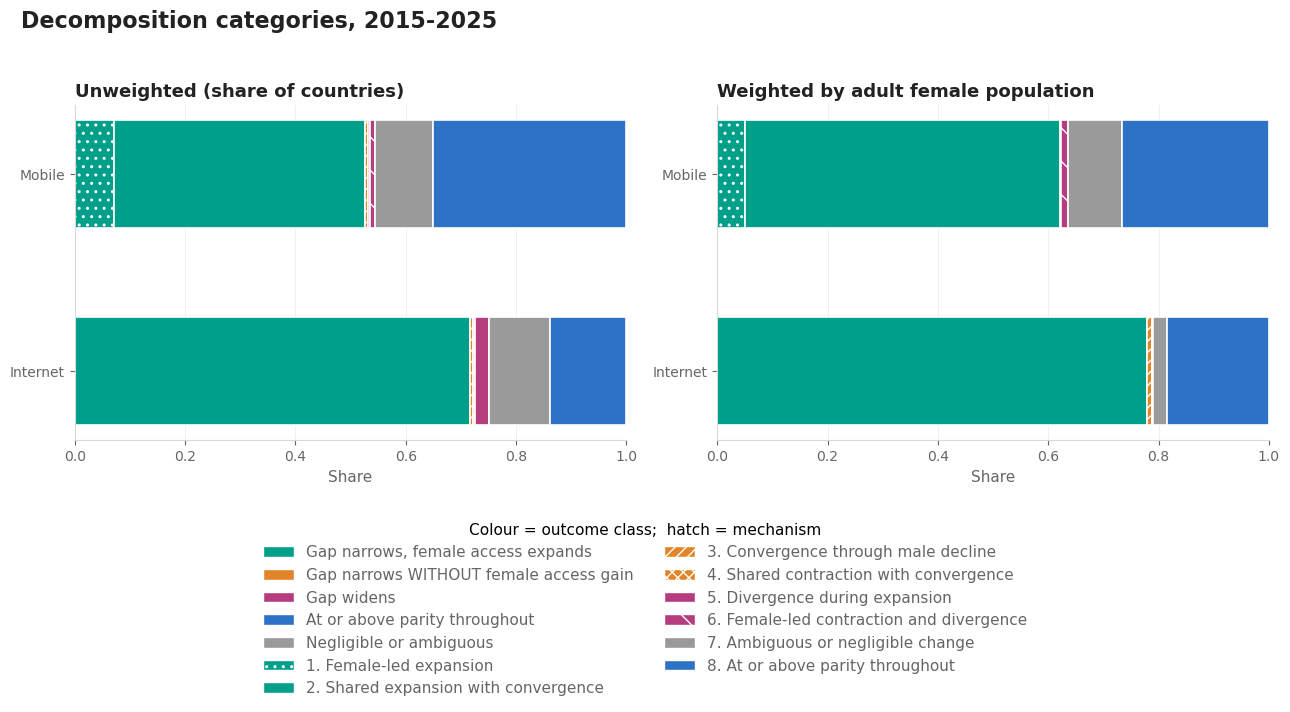

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, weighting in zip(axes, ['share_unweighted', 'share_pop_weighted']):
    block = cat_global[cat_global['interval'] == PRIMARY]
    left = dict.fromkeys(params.COHERENT_GGI['indicators'], 0.0)
    for _, row in block.sort_values(['indicator', 'category']).iterrows():
        ind = row['indicator']
        y = params.COHERENT_GGI['indicators'].index(ind)
        code_ = int(row['category'])
        ax.barh(y, row[weighting], left=left[ind], height=0.55,
                edgecolor='white', linewidth=1.2, **cat_style(code_))
        left[ind] += row[weighting]

    ax.set_yticks(range(len(params.COHERENT_GGI['indicators'])))
    ax.set_yticklabels([i.capitalize() for i in params.COHERENT_GGI['indicators']])
    ax.set_xlim(0, 1)
    title = 'Unweighted (share of countries)' if weighting == 'share_unweighted' \
        else 'Weighted by adult female population'
    tidy(ax, title=title, xlabel='Share')
    ax.grid(axis='y', visible=False)
    ax.grid(axis='x', color=GRID, linewidth=0.5, alpha=0.6)

handles = [mpatches.Patch(facecolor=CAT_COLOUR[int(c)], edgecolor='white',
                          hatch=CAT_HATCH[int(c)], label=f'{int(c)}. {CAT_LABEL[c]}')
           for c in CATS['code']]
class_handles = [mpatches.Patch(facecolor=CLASS_COLOUR[k], edgecolor='white', label=v)
                 for k, v in CLASS_LABEL.items()]
fig.legend(handles=class_handles + handles, loc='lower center', ncol=2, frameon=False,
           fontsize=STYLE['tick_fs'], labelcolor=MUTED, bbox_to_anchor=(0.5, -0.42),
           title='Colour = outcome class;  hatch = mechanism', title_fontsize=STYLE['tick_fs'])
fig.suptitle(f'Decomposition categories, {PRIMARY}', fontsize=STYLE['title_fs'],
             color=INK, fontweight='bold', x=0.02, ha='left')
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIGDIR / 'global_category_shares.png', dpi=STYLE['dpi'], bbox_inches='tight')
cat_global[cat_global['interval'] == PRIMARY].round(4)

## Regional stacked bars

  regional_category_shares_internet.png


  regional_category_shares_mobile.png


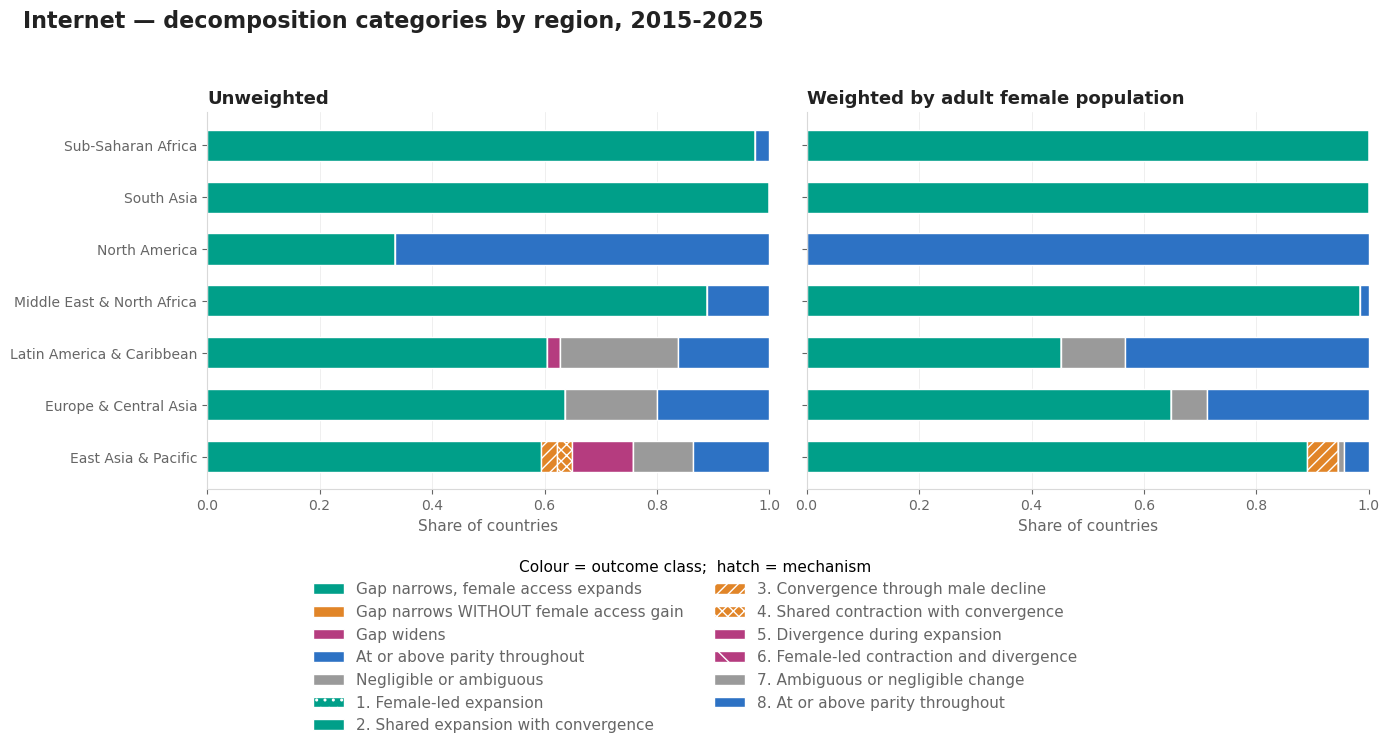

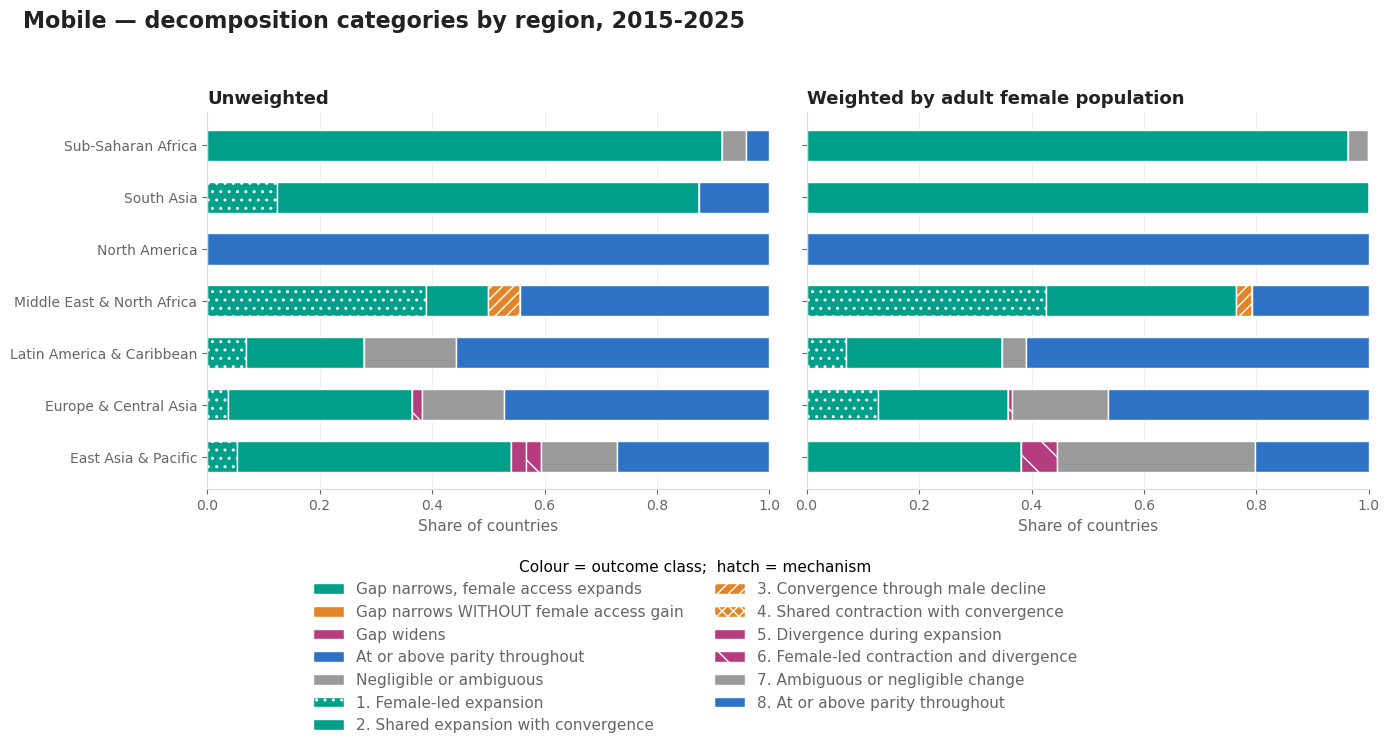

In [5]:
for indicator in params.COHERENT_GGI['indicators']:
    block = cat_region[(cat_region['interval'] == PRIMARY)
                       & (cat_region['indicator'] == indicator)]
    regions = sorted(block['region'].dropna().unique())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
    for ax, weighting in zip(axes, ['share_unweighted', 'share_pop_weighted']):
        left = dict.fromkeys(regions, 0.0)
        for _, row in block.sort_values(['region', 'category']).iterrows():
            region, code_ = row['region'], int(row['category'])
            y = regions.index(region)
            ax.barh(y, row[weighting], left=left[region], height=0.6,
                    edgecolor='white', linewidth=1.0, **cat_style(code_))
            left[region] += row[weighting]
        ax.set_yticks(range(len(regions)))
        ax.set_yticklabels(regions)
        ax.set_xlim(0, 1)
        title = 'Unweighted' if weighting == 'share_unweighted' else 'Weighted by adult female population'
        tidy(ax, title=title, xlabel='Share of countries')
        ax.grid(axis='y', visible=False)
        ax.grid(axis='x', color=GRID, linewidth=0.5, alpha=0.6)

    fig.legend(handles=class_handles + handles, loc='lower center', ncol=2, frameon=False,
               fontsize=STYLE['tick_fs'], labelcolor=MUTED, bbox_to_anchor=(0.5, -0.36),
               title='Colour = outcome class;  hatch = mechanism', title_fontsize=STYLE['tick_fs'])
    fig.suptitle(f'{indicator.capitalize()} — decomposition categories by region, {PRIMARY}',
                 fontsize=STYLE['title_fs'], color=INK, fontweight='bold', x=0.02, ha='left')
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(FIGDIR / f'regional_category_shares_{indicator}.png',
                dpi=STYLE['dpi'], bbox_inches='tight')
    print(f'  regional_category_shares_{indicator}.png')

## Female against male growth

Each point is a country over 2015–2025. The diagonal `y = x` is the **convergence/divergence
boundary**: above it female adoption grew proportionally faster and the gap narrowed; below it the
gap widened. The axes are log changes, so the vertical distance from the diagonal *is*
`delta_log_GGI`.

The quadrants matter for interpretation. Only the upper-right quadrant above the diagonal is both a
parity improvement and an access expansion. Points left of the vertical zero line had female
adoption fall; points below the horizontal zero line had male adoption fall.

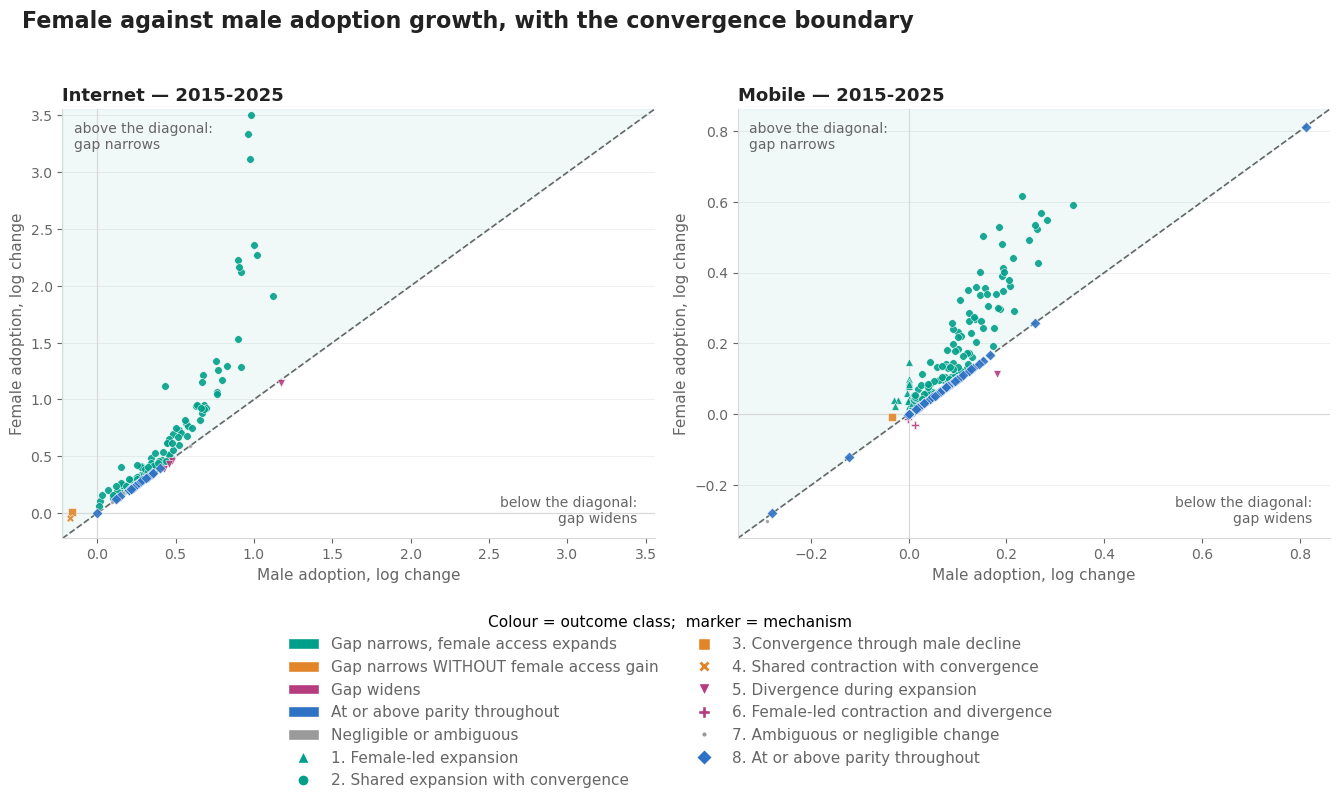

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6), sharex=False)

for ax, indicator in zip(axes, params.COHERENT_GGI['indicators']):
    block = country[(country['interval'] == PRIMARY) & (country['indicator'] == indicator)]
    # male_component is -(log change in male adoption); plot the raw male log change
    x = block['male_log_change']
    y = block['female_component']
    lim = [min(x.min(), y.min()) - 0.05, max(x.max(), y.max()) + 0.05]

    ax.axhline(0, color=GRID, linewidth=0.9)
    ax.axvline(0, color=GRID, linewidth=0.9)
    ax.plot(lim, lim, ls='--', color=MUTED, linewidth=1.2, zorder=2)
    ax.fill_between(lim, lim, [lim[1]] * 2, color=PALETTE[0], alpha=0.06, zorder=1)

    for code_ in sorted(block['category'].dropna().unique()):
        pts = block[block['category'] == code_]
        ax.scatter(pts['male_log_change'], pts['female_component'], s=30, alpha=0.9,
                   color=CAT_COLOUR[int(code_)], edgecolor='white', linewidth=0.4, zorder=3,
                   marker={1:'^',2:'o',3:'s',4:'X',5:'v',6:'P',7:'.',8:'D'}[int(code_)])

    ax.text(0.02, 0.97, 'above the diagonal:\ngap narrows', transform=ax.transAxes,
            va='top', ha='left', fontsize=STYLE['tick_fs'] - 1, color=MUTED)
    ax.text(0.97, 0.03, 'below the diagonal:\ngap widens', transform=ax.transAxes,
            va='bottom', ha='right', fontsize=STYLE['tick_fs'] - 1, color=MUTED)
    tidy(ax, title=f'{indicator.capitalize()} — {PRIMARY}',
         xlabel='Male adoption, log change', ylabel='Female adoption, log change')
    ax.set_xlim(lim); ax.set_ylim(lim)

marker_handles = [plt.Line2D([], [], linestyle='None', markersize=8,
                             marker={1:'^',2:'o',3:'s',4:'X',5:'v',6:'P',7:'.',8:'D'}[int(c)],
                             markerfacecolor=CAT_COLOUR[int(c)], markeredgecolor='white',
                             label=f'{int(c)}. {CAT_LABEL[c]}') for c in CATS['code']]
fig.legend(handles=class_handles + marker_handles, loc='lower center', ncol=2, frameon=False,
           fontsize=STYLE['tick_fs'], labelcolor=MUTED, bbox_to_anchor=(0.5, -0.34),
           title='Colour = outcome class;  marker = mechanism', title_fontsize=STYLE['tick_fs'])
fig.suptitle('Female against male adoption growth, with the convergence boundary',
             fontsize=STYLE['title_fs'], color=INK, fontweight='bold', x=0.02, ha='left')
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIGDIR / 'female_vs_male_growth.png', dpi=STYLE['dpi'], bbox_inches='tight')

## Map of decomposition categories

  category_map.png  (grey = excluded, no log change defined)


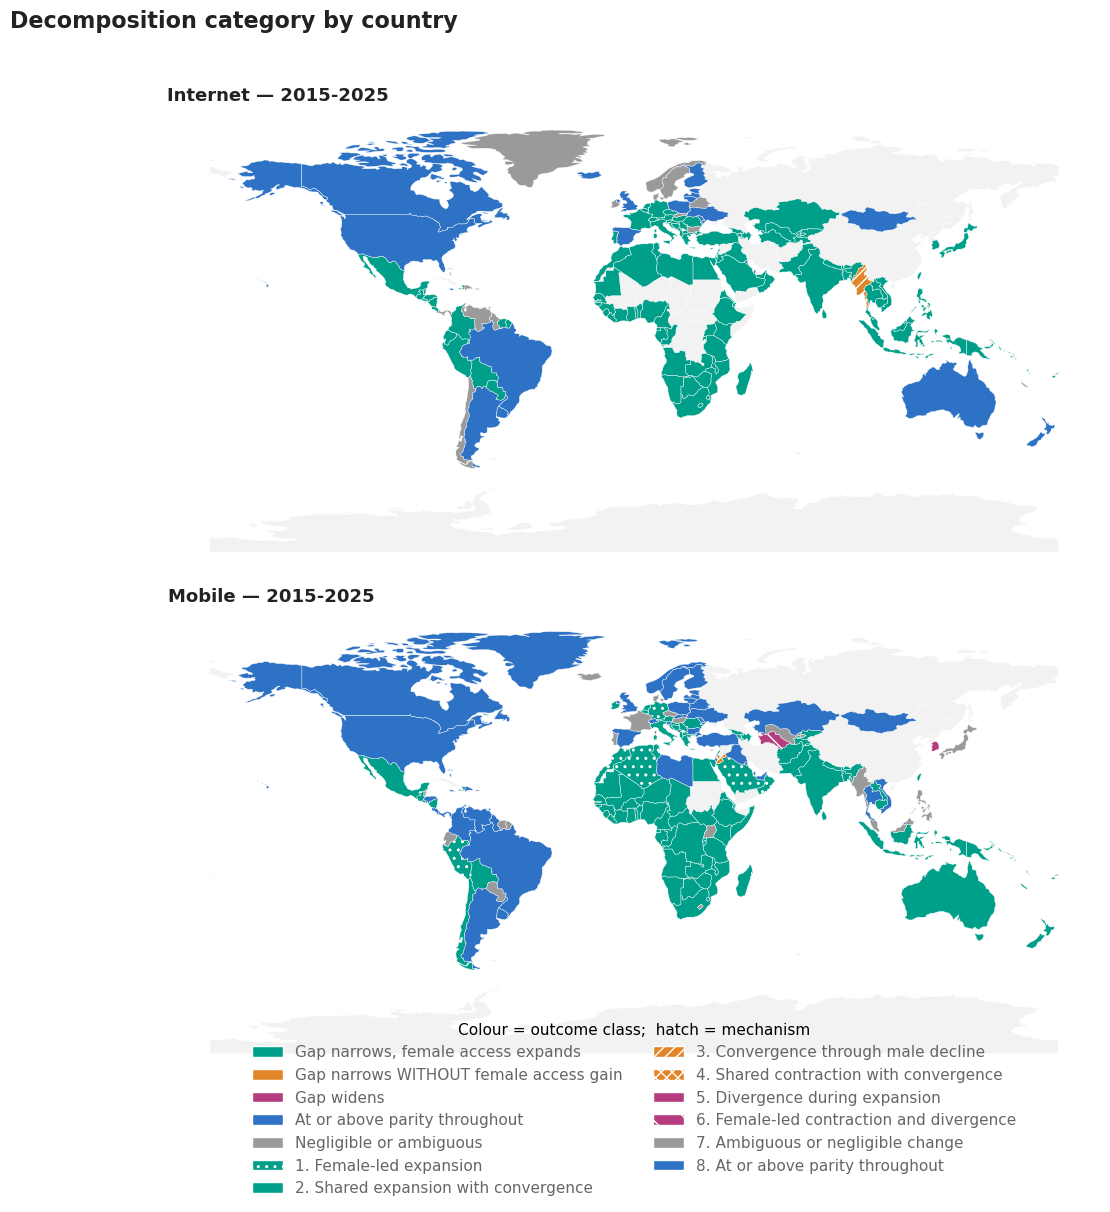

In [7]:
world = utils.load_world()
fig, axes = plt.subplots(2, 1, figsize=(13, 12))

for ax, indicator in zip(axes, params.COHERENT_GGI['indicators']):
    block = country[(country['interval'] == PRIMARY) & (country['indicator'] == indicator)]
    merged = world.merge(block[['gid_0', 'category']], left_on='iso_a3', right_on='gid_0', how='left')

    world.plot(ax=ax, color='#f2f2f2', edgecolor='white', linewidth=0.3)
    for code_ in sorted(block['category'].dropna().unique()):
        sub = merged[merged['category'] == code_]
        if len(sub):
            sub.plot(ax=ax, edgecolor='white', linewidth=0.3, **cat_style(code_))
    ax.set_title(f'{indicator.capitalize()} — {PRIMARY}', fontsize=STYLE['label_fs'],
                 color=INK, fontweight='bold', loc='left')
    ax.axis('off')

fig.legend(handles=class_handles + handles, loc='lower center', ncol=2, frameon=False,
           fontsize=STYLE['tick_fs'], labelcolor=MUTED, bbox_to_anchor=(0.5, -0.02),
           title='Colour = outcome class;  hatch = mechanism', title_fontsize=STYLE['tick_fs'])
fig.suptitle('Decomposition category by country', fontsize=STYLE['title_fs'],
             color=INK, fontweight='bold', x=0.02, ha='left')
fig.tight_layout(rect=[0, 0.08, 1, 0.96])
fig.savefig(FIGDIR / 'category_map.png', dpi=STYLE['dpi'], bbox_inches='tight')
print('  category_map.png  (grey = excluded, no log change defined)')

## Largest parity changes

Twenty largest improvements and deteriorations per indicator, showing which component drives each.
"Improvement" here refers to **parity** only; the access columns say whether women actually gained.

In [8]:
display(extremes[(extremes['indicator'] == 'internet')
                 & (extremes['rank_type'] == 'largest parity improvement')].head(20).round(4))
extremes[(extremes['indicator'] == 'internet')
         & (extremes['rank_type'] == 'largest parity deterioration')].head(20).round(4)

,indicator,gid_0,country,region,delta_log_ggi,female_component,male_component,category_label,parity_direction,female_access_direction,parity_improved_without_access_gain,rank_type
0,internet,SLE,Sierra Leone,Sub-Saharan Africa,2.5286,3.5074,-0.9788,Shared expansion with convergence,improving,expanding,False,largest parity improvement
1,internet,TGO,Togo,Sub-Saharan Africa,2.3737,3.3386,-0.9649,Shared expansion with convergence,improving,expanding,False,largest parity improvement
2,internet,LBR,Liberia,Sub-Saharan Africa,2.1432,3.1155,-0.9723,Shared expansion with convergence,improving,expanding,False,largest parity improvement
3,internet,ETH,Ethiopia,Sub-Saharan Africa,1.3561,2.3583,-1.0022,Shared expansion with convergence,improving,expanding,False,largest parity improvement
4,internet,GIN,Guinea,Sub-Saharan Africa,1.3326,2.2303,-0.8977,Shared expansion with convergence,improving,expanding,False,largest parity improvement
5,internet,PAK,Pakistan,South Asia,1.2637,2.1658,-0.9021,Shared expansion with convergence,improving,expanding,False,largest parity improvement
6,internet,BEN,Benin,Sub-Saharan Africa,1.2587,2.2762,-1.0175,Shared expansion with convergence,improving,expanding,False,largest parity improvement
7,internet,GNB,Guinea-Bissau,Sub-Saharan Africa,1.2058,2.1200,-0.9143,Shared expansion with convergence,improving,expanding,False,largest parity improvement
8,internet,MWI,Malawi,Sub-Saharan Africa,0.7912,1.9133,-1.1221,Shared expansion with convergence,improving,expanding,False,largest parity improvement
9,internet,DJI,Djibouti,Middle East & North Africa,0.6835,1.1153,-0.4318,Shared expansion with convergence,improving,expanding,False,largest parity improvement


,indicator,gid_0,country,region,delta_log_ggi,female_component,male_component,category_label,parity_direction,female_access_direction,parity_improved_without_access_gain,rank_type
20,internet,GUM,Guam,East Asia & Pacific,-0.0407,0.3855,-0.4262,Divergence during expansion,worsening,expanding,False,largest parity deterioration
21,internet,NIU,Niue,East Asia & Pacific,-0.0294,1.1450,-1.1744,Divergence during expansion,worsening,expanding,False,largest parity deterioration
22,internet,KIR,Kiribati,East Asia & Pacific,-0.0261,0.4296,-0.4557,Divergence during expansion,worsening,expanding,False,largest parity deterioration
23,internet,ASM,American Samoa,East Asia & Pacific,-0.0175,0.4617,-0.4792,Divergence during expansion,worsening,expanding,False,largest parity deterioration
24,internet,ATG,Antigua & Barbuda,Latin America & Caribbean,-0.0116,0.3087,-0.3203,Divergence during expansion,worsening,expanding,False,largest parity deterioration
25,internet,NCL,New Caledonia,East Asia & Pacific,-0.0095,0.3507,-0.3602,Ambiguous or negligible change,stable,expanding,False,largest parity deterioration
26,internet,PAN,Panama,Latin America & Caribbean,-0.0075,0.3315,-0.3390,Ambiguous or negligible change,stable,expanding,False,largest parity deterioration
27,internet,BHS,Bahamas,Latin America & Caribbean,-0.0072,0.2931,-0.3003,Ambiguous or negligible change,stable,expanding,False,largest parity deterioration
28,internet,GUY,Guyana,Latin America & Caribbean,-0.0061,0.5876,-0.5938,Ambiguous or negligible change,stable,expanding,False,largest parity deterioration
29,internet,GRD,Grenada,Latin America & Caribbean,-0.0061,0.3186,-0.3248,Ambiguous or negligible change,stable,expanding,False,largest parity deterioration


In [9]:
display(extremes[(extremes['indicator'] == 'mobile')
                 & (extremes['rank_type'] == 'largest parity improvement')].head(20).round(4))
extremes[(extremes['indicator'] == 'mobile')
         & (extremes['rank_type'] == 'largest parity deterioration')].head(20).round(4)

,indicator,gid_0,country,region,delta_log_ggi,female_component,male_component,category_label,parity_direction,female_access_direction,parity_improved_without_access_gain,rank_type
40,mobile,TCD,Chad,Sub-Saharan Africa,0.3846,0.6167,-0.2322,Shared expansion with convergence,improving,expanding,False,largest parity improvement
41,mobile,NER,Niger,Sub-Saharan Africa,0.3514,0.5033,-0.1519,Shared expansion with convergence,improving,expanding,False,largest parity improvement
42,mobile,PAK,Pakistan,South Asia,0.3424,0.5275,-0.1851,Shared expansion with convergence,improving,expanding,False,largest parity improvement
43,mobile,BEN,Benin,Sub-Saharan Africa,0.2993,0.5695,-0.2702,Shared expansion with convergence,improving,expanding,False,largest parity improvement
44,mobile,COD,DR Congo,Sub-Saharan Africa,0.2882,0.4795,-0.1913,Shared expansion with convergence,improving,expanding,False,largest parity improvement
45,mobile,SSD,South Sudan,Sub-Saharan Africa,0.2749,0.5337,-0.2588,Shared expansion with convergence,improving,expanding,False,largest parity improvement
46,mobile,MWI,Malawi,Sub-Saharan Africa,0.2643,0.5481,-0.2837,Shared expansion with convergence,improving,expanding,False,largest parity improvement
47,mobile,BGD,Bangladesh,South Asia,0.2607,0.5230,-0.2622,Shared expansion with convergence,improving,expanding,False,largest parity improvement
48,mobile,TGO,Togo,Sub-Saharan Africa,0.2559,0.4010,-0.1450,Shared expansion with convergence,improving,expanding,False,largest parity improvement
49,mobile,BFA,Burkina Faso,Sub-Saharan Africa,0.2558,0.5915,-0.3357,Shared expansion with convergence,improving,expanding,False,largest parity improvement


,indicator,gid_0,country,region,delta_log_ggi,female_component,male_component,category_label,parity_direction,female_access_direction,parity_improved_without_access_gain,rank_type
60,mobile,KIR,Kiribati,East Asia & Pacific,-0.0660,0.1145,-0.1805,Divergence during expansion,worsening,expanding,False,largest parity deterioration
61,mobile,TKM,Turkmenistan,Europe & Central Asia,-0.0419,-0.0288,-0.0131,Female-led contraction and divergence,worsening,contracting,False,largest parity deterioration
62,mobile,KOR,South Korea,East Asia & Pacific,-0.0124,-0.0142,0.0018,Female-led contraction and divergence,worsening,contracting,False,largest parity deterioration
63,mobile,MMR,Myanmar,East Asia & Pacific,-0.0099,-0.3000,0.2901,Ambiguous or negligible change,stable,contracting,False,largest parity deterioration
64,mobile,ABW,Aruba,Latin America & Caribbean,0.0000,0.0367,-0.0367,At or above parity throughout,stable,expanding,False,largest parity deterioration
65,mobile,JAM,Jamaica,Latin America & Caribbean,0.0000,0.0968,-0.0968,At or above parity throughout,stable,expanding,False,largest parity deterioration
66,mobile,KAZ,Kazakhstan,Europe & Central Asia,0.0000,0.0554,-0.0554,At or above parity throughout,stable,expanding,False,largest parity deterioration
67,mobile,KNA,St Kitts & Nevis,Latin America & Caribbean,0.0000,0.0624,-0.0624,At or above parity throughout,stable,expanding,False,largest parity deterioration
68,mobile,KWT,Kuwait,Middle East & North Africa,0.0000,0.0000,-0.0000,At or above parity throughout,stable,stable,False,largest parity deterioration
69,mobile,LBY,Libya,Middle East & North Africa,0.0000,0.0000,-0.0000,At or above parity throughout,stable,stable,False,largest parity deterioration


## Regional aggregate decomposition

Regional levels are the population-weighted means of country levels, each sex on its **own**
denominator: regional female level weights by adult female population, regional male level by adult
male population. Weights are fixed at 2015 — the UN file stops at 2024 so 2025 has no population of
its own, and fixed weights keep the identity exact by preventing population composition change from
entering a decomposition that only claims to measure adoption change.

,indicator,interval,region,n_countries,female_level_t0,female_level_t1,male_level_t0,male_level_t1,ggi_t0,ggi_t1,female_component,male_component,delta_log_ggi,parity_direction,female_access_direction
0,internet,2015-2025,East Asia & Pacific,37,0.6120,0.8402,0.6696,0.8825,0.9139,0.9521,0.3169,-0.2760,0.0409,improving,expanding
1,internet,2015-2025,Europe & Central Asia,55,0.7220,0.9291,0.7578,0.9452,0.9528,0.9830,0.2522,-0.2210,0.0312,improving,expanding
2,internet,2015-2025,Latin America & Caribbean,43,0.6452,0.8701,0.6677,0.8806,0.9663,0.9881,0.2991,-0.2768,0.0223,improving,expanding
3,internet,2015-2025,Middle East & North Africa,18,0.5661,0.8309,0.7390,0.9490,0.7660,0.8755,0.3837,-0.2500,0.1337,improving,expanding
4,internet,2015-2025,North America,3,0.8044,1.0000,0.8044,1.0000,0.9999,1.0000,0.2177,-0.2176,0.0001,stable,expanding
5,internet,2015-2025,South Asia,7,0.2186,0.5973,0.4019,0.7795,0.5440,0.7663,1.0050,-0.6624,0.3426,improving,expanding
6,internet,2015-2025,Sub-Saharan Africa,38,0.1825,0.4853,0.3013,0.5868,0.6059,0.8269,0.9778,-0.6668,0.3110,improving,expanding
21,mobile,2015-2025,East Asia & Pacific,37,0.8380,0.8950,0.8796,0.9244,0.9527,0.9683,0.0658,-0.0496,0.0162,improving,expanding
22,mobile,2015-2025,Europe & Central Asia,55,0.8917,0.9468,0.9149,0.9561,0.9746,0.9903,0.0600,-0.0441,0.0159,improving,expanding
23,mobile,2015-2025,Latin America & Caribbean,43,0.8234,0.8847,0.8354,0.8861,0.9856,0.9985,0.0718,-0.0589,0.0130,improving,expanding


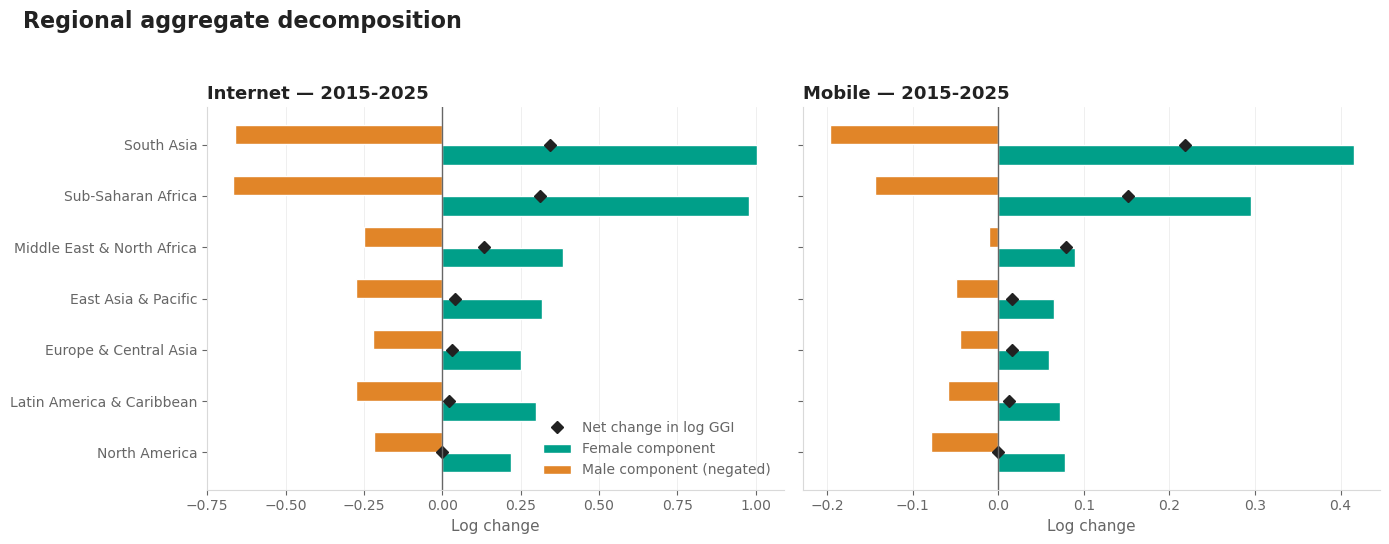

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for ax, indicator in zip(axes, params.COHERENT_GGI['indicators']):
    block = (regional[(regional['interval'] == PRIMARY) & (regional['indicator'] == indicator)]
             .sort_values('delta_log_ggi'))
    y = np.arange(len(block))
    ax.barh(y - 0.2, block['female_component'], height=0.38, color=PALETTE[0],
            edgecolor='white', label='Female component')
    ax.barh(y + 0.2, block['male_component'], height=0.38, color=PALETTE[1],
            edgecolor='white', label='Male component (negated)')
    ax.plot(block['delta_log_ggi'], y, 'D', color=INK, markersize=6, label='Net change in log GGI')
    ax.axvline(0, color=MUTED, linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(block['region'])
    tidy(ax, title=f'{indicator.capitalize()} — {PRIMARY}', xlabel='Log change')
    ax.grid(axis='y', visible=False)
    ax.grid(axis='x', color=GRID, linewidth=0.5, alpha=0.6)

axes[0].legend(frameon=False, fontsize=STYLE['tick_fs'] - 1, loc='lower right', labelcolor=MUTED)
fig.suptitle('Regional aggregate decomposition', fontsize=STYLE['title_fs'],
             color=INK, fontweight='bold', x=0.02, ha='left')
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIGDIR / 'regional_aggregate_decomposition.png', dpi=STYLE['dpi'], bbox_inches='tight')
regional[regional['interval'] == PRIMARY].round(4)

## Generated summary

In [11]:
def summary_text():
    """compose the summary from the tables, keeping parity and access strictly separate"""
    lines = [
        'Because the coherent gender gap index is a ratio of predicted female to predicted male '
        'adoption, its log change decomposes exactly into a female and a male term. The identity '
        f"holds to {identity['max_abs_residual'].iloc[0]:.0e} across "
        f"{int(identity['n_rows'].iloc[0])} country-periods. This separation matters because a "
        'narrowing gap can reflect women gaining access, men losing it, or both sexes losing access '
        'with men losing more; only the first is an expansion of digital access for women.']

    for ind in params.COHERENT_GGI['indicators']:
        exc = exclusions[(exclusions['indicator'] == ind) & (exclusions['interval'] == PRIMARY)].iloc[0]
        g = cat_global[(cat_global['indicator'] == ind) & (cat_global['interval'] == PRIMARY)]
        g = g.set_index('category')
        shared = g.loc[2]
        no_access = g.loc[list(NO_ACCESS_GAIN)]
        diverge = g.loc[5]

        lines.append(
            f"For {ind} over 2015-2025, {int(exc['n_included'])} of "
            f"{int(exc['n_countries_available'])} countries have a defined log change; "
            f"{int(exc['n_excluded'])} are excluded because a predicted level is exactly zero at an "
            f"endpoint. Of those included, {int(shared['n_countries'])} "
            f"({shared['share_unweighted']:.1%} of countries, {shared['share_pop_weighted']:.1%} of "
            'adult women) fall into shared expansion with convergence: both sexes gained access and '
            'women gained proportionally faster, so parity improved alongside access expansion. A '
            f"further {int(diverge['n_countries'])} ({diverge['share_unweighted']:.1%}) show "
            'divergence during expansion, where access grew but men gained faster and the gap widened.')

        at_parity = g.loc[8] if 8 in g.index else None
        if at_parity is not None and int(at_parity['n_countries']):
            lines.append(
                f"A further {int(at_parity['n_countries'])} {ind} countries "
                f"({at_parity['share_unweighted']:.1%} of countries, "
                f"{at_parity['share_pop_weighted']:.1%} of adult women) were at or above parity at "
                'both endpoints. They are reported as a standing state rather than as change: there '
                'was no gap against women to close. They are retained in the denominator, because '
                'excluding them would remove countries non-randomly by region and income level.')

        n_no_access = int(no_access['n_countries'].sum())
        if n_no_access:
            names = country[(country['interval'] == PRIMARY) & (country['indicator'] == ind)
                            & country['parity_improved_without_access_gain']]['country'].tolist()
            lines.append(
                f"In {n_no_access} {ind} case(s) - {', '.join(names)} - the gap narrowed without "
                'women gaining access: either male adoption fell while female adoption was flat, or '
                'both fell and male adoption fell faster. These are improvements in parity, not in '
                'digital access, and should not be reported as the latter.')

    # regional aggregate: state parity and access separately
    for ind in params.COHERENT_GGI['indicators']:
        r = regional[(regional['interval'] == PRIMARY) & (regional['indicator'] == ind)]
        improving = r[r['parity_direction'] == 'improving']
        expanding = r[r['female_access_direction'] == 'expanding']
        biggest = r.loc[r['delta_log_ggi'].idxmax()]
        lines.append(
            f"At regional level for {ind}, {len(improving)} of {len(r)} regions show improving "
            f"parity and {len(expanding)} of {len(r)} show expanding female access. The largest "
            f"parity gain is {biggest['region']} ({biggest['delta_log_ggi']:+.3f} log points), "
            f"where the female component contributes {biggest['female_component']:+.3f} and the "
            f"male component {biggest['male_component']:+.3f} - that is, female adoption rose "
            f"faster than male adoption, both having risen.")

    lines.append(
        'Two caveats bound the country-level results. The excluded countries are not a random '
        'subset: they are those whose predicted female level sits on the zero floor of the level '
        'model, and they are among the most gender-unequal in the sample, so the reported '
        'distribution understates the tail. And an epsilon substitution was tested but not adopted, '
        'because it changes no existing estimate and only manufactures a log change where the '
        'underlying level is exactly zero.')

    return '\n\n'.join(lines)


text = summary_text()
out = params.DOC / 'decomposition_coherent_ggi.md'
out.write_text('# Decomposition of coherent-GGI change\n\n'
               '<!-- generated by src/analysis/09_02_coherent_ggi_decomposition.ipynb — do not edit by hand -->\n\n'
               + text + '\n')
print(f'written to {out.relative_to(params.ROOT)}\n')
print(text)

written to doc/decomposition_coherent_ggi.md

Because the coherent gender gap index is a ratio of predicted female to predicted male adoption, its log change decomposes exactly into a female and a male term. The identity holds to 9e-16 across 5424 country-periods. This separation matters because a narrowing gap can reflect women gaining access, men losing it, or both sexes losing access with men losing more; only the first is an expansion of digital access for women.

For internet over 2015-2025, 201 of 211 countries have a defined log change; 10 are excluded because a predicted level is exactly zero at an endpoint. Of those included, 144 (71.6% of countries, 77.9% of adult women) fall into shared expansion with convergence: both sexes gained access and women gained proportionally faster, so parity improved alongside access expansion. A further 5 (2.5%) show divergence during expansion, where access grew but men gained faster and the gap widened.

A further 28 internet countries (13.9%

## Notes

- Figures write to `outputs/fig/ggi_decomposition/`; every table is in `outputs/tables/` under the
  `ggi_decomposition_` prefix.
- **Parity and access are reported separately throughout.** `parity_direction` and
  `female_access_direction` are distinct columns on every country-period row, and categories 3 and 4
  carry `parity_improved_without_access_gain = True`. They are hatched in every chart so the
  distinction does not rest on recalling a colour.
- Weights are fixed at the 2015 adult population, by sex. See the regional section for why.